In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 120

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline

# ============================================================
# STEP 0 — Paths
# ============================================================

BASE = "../../data/macro_processed1"

paths = {
    "sp500":        f"{BASE}/other/sp500_processed.csv",
    "tbill_3m":     f"{BASE}/other/3m_yield_processed.csv",

    # Inflation indices (levels)
    "cpi":          f"{BASE}/inflation/cpi_processed.csv",
    "pce":          f"{BASE}/inflation/PCE_price_index_processed.csv",
    "ppi":          f"{BASE}/inflation/PPI_inflation_processed.csv",

    # Growth indicators (levels)
    "indprod":      f"{BASE}/ec_growth/industrial_production_processed.csv",
    "retail_sales": f"{BASE}/ec_growth/retail_sales_processed.csv",
    "inventories":  f"{BASE}/ec_growth/tot_business_inventories_processed.csv",
    "export_px":    f"{BASE}/ec_growth/export_price_index_processed.csv",
    "import_px":    f"{BASE}/ec_growth/import_price_index_processed.csv",
    "unemp":        f"{BASE}/ec_growth/unemployment_processed.csv",

    # Money and policy
    "m2":           f"{BASE}/mon_policy/m2_real_money_supply_processed.csv",
    "fedfunds":     f"{BASE}/mon_policy/fedfunds_processed.csv",
    "discount_rate":f"{BASE}/mon_policy/fed_reserve_discount_rate_processed.csv",

    # Yields and spreads
    "spread_10y_2y":f"{BASE}/mkt_vol/10y_2y_spread_processed.csv",
    "nat_fin_cond": f"{BASE}/mkt_vol/nat_fin_condition_indx_processed.csv",
    "nasdaq_vol":   f"{BASE}/mkt_vol/nasdaq_vol_indx_processed.csv",
    "hy_spread":    f"{BASE}/other/bofa_highyield_spread_processed.csv",
    "y2":           f"{BASE}/other/2y_yield_processed.csv",
    "y10":          f"{BASE}/other/10y_yield_processed.csv",
}

# ============================================================
# STEP 1 — Monthly geometric EMRP, then quarterly aggregation
# ============================================================

sp = pd.read_csv(paths["sp500"], parse_dates=["date"]).set_index("date").sort_index()
sp["sp500_geo_m"] = sp["pct_change_mom"] / 100.0
sp_m = sp.resample("ME").last()[["sp500_geo_m"]]

rf = pd.read_csv(paths["tbill_3m"], parse_dates=["date"]).set_index("date").sort_index()
rf["r_daily"] = (rf["value"] / 100.0) / 252.0
rf_m = rf["r_daily"].resample("ME").apply(lambda x: (1 + x).prod() - 1)
rf_m = rf_m.to_frame("rf_geo_m")

m = sp_m.join(rf_m, how="inner")
m["EMRP_geo_m"] = m["sp500_geo_m"] - m["rf_geo_m"]

emrp_q = (1 + m["EMRP_geo_m"]).resample("QE").prod() - 1
emrp_q = emrp_q.to_frame("EMRP_q")
emrp_q["EMRP_next_q"] = emrp_q["EMRP_q"].shift(-1)

# ============================================================
# STEP 2 — Macro predictors (QoQ) + levels + 1Q lag
# ============================================================

def load_monthly(path, date_col="date", value_col="value", name=None):
    df = pd.read_csv(path, parse_dates=[date_col]).set_index(date_col).sort_index()
    if name is None:
        name = value_col
    return df[[value_col]].rename(columns={value_col: name}).resample("ME").last()

def safe_pct_change(df, lag=1):
    out = df.replace(0, np.nan).pct_change(lag) * 100.0
    out = out.replace([np.inf, -np.inf], np.nan)
    return out

# Load all monthly macro series
cpi_m  = load_monthly(paths["cpi"],          name="cpi")
pce_m  = load_monthly(paths["pce"],          name="pce")
ppi_m  = load_monthly(paths["ppi"],          name="ppi")
ind_m  = load_monthly(paths["indprod"],      name="indprod")
ret_m  = load_monthly(paths["retail_sales"], name="retail_sales")
inv_m  = load_monthly(paths["inventories"],  name="inventories")
exp_m  = load_monthly(paths["export_px"],    name="export_px")
imp_m  = load_monthly(paths["import_px"],    name="import_px")
m2_m   = load_monthly(paths["m2"],           name="m2")

unemp_m  = load_monthly(paths["unemp"],      name="unemp_rate")
fedf_m   = load_monthly(paths["fedfunds"],   name="fedfunds")
disc_m   = load_monthly(paths["discount_rate"], name="discount_rate")
spread_m = load_monthly(paths["spread_10y_2y"], name="spread_10y_2y")
natfin_m = load_monthly(paths["nat_fin_cond"], name="nat_fin_cond")
nasd_m   = load_monthly(paths["nasdaq_vol"], name="nasdaq_vol")
hy_m     = load_monthly(paths["hy_spread"],  name="hy_spread")
y2_m     = load_monthly(paths["y2"],         name="y2")
y3m_m    = load_monthly(paths["y3m"],        name="y3m")
y10_m    = load_monthly(paths["y10"],        name="y10")

macro_levels_m = pd.concat([
    cpi_m, pce_m, ppi_m,
    ind_m, ret_m, inv_m,
    exp_m, imp_m,
    unemp_m, m2_m, fedf_m, disc_m,
    spread_m, natfin_m, nasd_m, hy_m,
    y2_m, y3m_m, y10_m
], axis=1)

macro_q_levels = macro_levels_m.resample("QE").last()

macro_q = safe_pct_change(macro_q_levels).add_suffix("_qoq")

level_vars = [
    "unemp_rate","fedfunds","discount_rate","spread_10y_2y",
    "nat_fin_cond","nasdaq_vol","hy_spread","y2","y3m","y10"
]

for col in level_vars:
    macro_q[col] = macro_q_levels[col]
    macro_q.drop(columns=[col + "_qoq"], errors="ignore", inplace=True)

# LAG ALL PREDICTORS BY ONE QUARTER
macro_q_lagged = macro_q.shift(1)

# ============================================================
# STEP 3 — Merge return + lagged macro
# ============================================================

reg_q = emrp_q.join(macro_q_lagged, how="inner").replace([np.inf, -np.inf], np.nan).dropna()
predictors = [c for c in reg_q.columns if c not in ["EMRP_q", "EMRP_next_q"]]

print("Quarterly sample size:", len(reg_q))

# ============================================================
# STEP 4 — Multivariate quarterly OLS
# ============================================================

df_multi_q = reg_q[["EMRP_next_q"] + predictors]
y_q = df_multi_q["EMRP_next_q"]
X_q = sm.add_constant(df_multi_q[predictors])

model_q = sm.OLS(y_q, X_q).fit()
print("\n=== QUARTERLY MULTIPLE OLS ===")
print(model_q.summary())

# ============================================================
# STEP 5 — Univariate quarterly regressions
# ============================================================

simple_rows_q = []
for var in predictors:
    tmp = reg_q[["EMRP_next_q", var]].dropna()
    if tmp.shape[0] < 10:
        continue
    y_s = tmp["EMRP_next_q"]
    X_s = sm.add_constant(tmp[[var]])
    res = sm.OLS(y_s, X_s).fit()

    simple_rows_q.append({
        "variable": var,
        "coef": res.params[var],
        "t_stat": res.tvalues[var],
        "p_value": res.pvalues[var],
        "R_squared": res.rsquared,
        "n_obs": int(res.nobs),
        "sign": "positive" if res.params[var] > 0 else "negative"
    })

simple_q_df = pd.DataFrame(simple_rows_q).sort_values("p_value")
print("\n=== QUARTERLY UNIVARIATE REGRESSIONS ===")
print(simple_q_df.to_string(index=False))

# ============================================================
# STEP 6 — LASSO (FORCE 6–10 VARIABLES)
# ============================================================

X_full_q = reg_q[predictors].values
y_full_q = reg_q["EMRP_next_q"].values

alphas = np.logspace(-3, 0, 100)
tol = 1e-6

best_alpha = None
best_coefs = None
best_k = None

for a in sorted(alphas, reverse=True):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=50000, random_state=0))
    ])
    pipe.fit(X_full_q, y_full_q)
    coefs = pipe.named_steps["lasso"].coef_
    k = np.sum(np.abs(coefs) > tol)

    if 6 <= k <= 10:
        best_alpha = a
        best_coefs = coefs
        best_k = k
        break

if best_alpha is None:
    a = alphas.min()
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=50000, random_state=0))
    ])
    pipe.fit(X_full_q, y_full_q)
    best_alpha = a
    best_coefs = pipe.named_steps["lasso"].coef_
    best_k = np.sum(np.abs(best_coefs) > tol)

selected_vars = [p for p, c in zip(predictors, best_coefs) if abs(c) > tol]

print("\n=== QUARTERLY LASSO (6–10 VARIABLES) ===")
print("alpha:", best_alpha)
print("nonzero:", best_k)
print("selected:", selected_vars)

print("\nLASSO coefficients:")
for p, c in sorted(zip(predictors, best_coefs), key=lambda x: -abs(x[1])):
    if abs(c) > tol:
        print(f"{p:20s} {c:+.5f}")

# ============================================================
# STEP 7 — Reduced OLS (post-LASSO)
# ============================================================

df_red_q = reg_q[["EMRP_next_q"] + selected_vars].dropna()
y_rq = df_red_q["EMRP_next_q"]
X_rq = sm.add_constant(df_red_q[selected_vars])

model_red_q = sm.OLS(y_rq, X_rq).fit()

print("\n=== REDUCED OLS (POST-LASSO) ===")
print(model_red_q.summary())

Quarterly sample size: 83

=== QUARTERLY MULTIPLE OLS ===
                            OLS Regression Results                            
Dep. Variable:            EMRP_next_q   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.245
Method:                 Least Squares   F-statistic:                     2.481
Date:                Mon, 01 Dec 2025   Prob (F-statistic):            0.00408
Time:                        21:53:20   Log-Likelihood:                 110.67
No. Observations:                  83   AIC:                            -183.3
Df Residuals:                      64   BIC:                            -137.4
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

/var/folders/h_/5wg7lw3n2djc8yh6g107mytm0000gn/T/ipykernel_44001/4218410839.py:80: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  out = df.replace(0, np.nan).pct_change(lag) * 100.0


In [81]:
# ==============================================
# OUT-OF-SAMPLE FORECASTING (EXPANDING WINDOW)
# SETUP: Selected-vars + Benchmark ONLY
# ==============================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120

# ---------------------------
# 1. LASSO-selected predictors
# ---------------------------
vars_sel = selected_vars.copy()
print("LASSO-selected variables:", vars_sel)

# ---------------------------
# Target + Predictors
# ---------------------------
y = reg_q["EMRP_next_q"]
X_sel = reg_q[vars_sel]

# ---------------------------
# OOS split date
# ---------------------------
split_date = "2015-12-31"

train_idx = X_sel.index <= split_date
test_idx  = X_sel.index > split_date

# Training/Test sets
X_train_sel = X_sel.loc[train_idx]
y_train_sel = y.loc[train_idx]
X_test_sel  = X_sel.loc[test_idx]
y_test_sel  = y.loc[test_idx]

print("Training size:", len(X_train_sel))
print("OOS size:", len(X_test_sel))

LASSO-selected variables: ['import_px_qoq', 'm2_qoq', 'unemp_rate', 'fedfunds', 'nat_fin_cond', 'y10']
Training size: 59
OOS size: 24


In [82]:
# ==============================================
# EXPANDING-WINDOW OOS FORECASTING — Selected Vars Only
# ==============================================

y_pred_sel = []
test_points = X_test_sel.index
n0 = len(X_train_sel)

for t in range(len(test_points)):

    model = LinearRegression()

    # expanding window
    X_train_t = X_sel.iloc[:(n0 + t)]
    y_train_t = y.iloc[:(n0 + t)]

    model.fit(X_train_t, y_train_t)

    # KEEP COLUMN NAMES → removes sklearn warnings
    x_t = X_test_sel.iloc[[t]]
    y_pred_sel.append(model.predict(x_t)[0])

# Convert to series
y_pred_sel = pd.Series(y_pred_sel, index=test_points)

print("First OOS predictions (selected vars):")
print(y_pred_sel.head())

First OOS predictions (selected vars):
date
2016-03-31    0.010917
2016-06-30    0.017310
2016-09-30   -0.008774
2016-12-31    0.012578
2017-03-31   -0.002173
Freq: QE-DEC, dtype: float64


In [83]:
# ==============================================
# OOS ACCURACY — Selected Vars + Benchmark ONLY
# ==============================================

# --- Selected-vars performance ---
rmse_sel = np.sqrt(mean_squared_error(y_test_sel, y_pred_sel))
mae_sel  = mean_absolute_error(y_test_sel, y_pred_sel)

# --- Benchmark (historical mean) ---
mean_bench = y_train_sel.mean()
y_bench = pd.Series(mean_bench, index=y_test_sel.index)

rmse_bench = np.sqrt(mean_squared_error(y_test_sel, y_bench))
mae_bench  = mean_absolute_error(y_test_sel, y_bench)

print("\n===== OUT-OF-SAMPLE FORECAST ACCURACY =====")
print(f"Selected-vars RMSE: {rmse_sel:.6f}")
print(f"Selected-vars MAE : {mae_sel:.6f}")
print("-------------------------------------------")
print(f"Benchmark RMSE:    {rmse_bench:.6f}")
print(f"Benchmark MAE:     {mae_bench:.6f}")


===== OUT-OF-SAMPLE FORECAST ACCURACY =====
Selected-vars RMSE: 0.084233
Selected-vars MAE : 0.059786
-------------------------------------------
Benchmark RMSE:    0.084682
Benchmark MAE:     0.063518


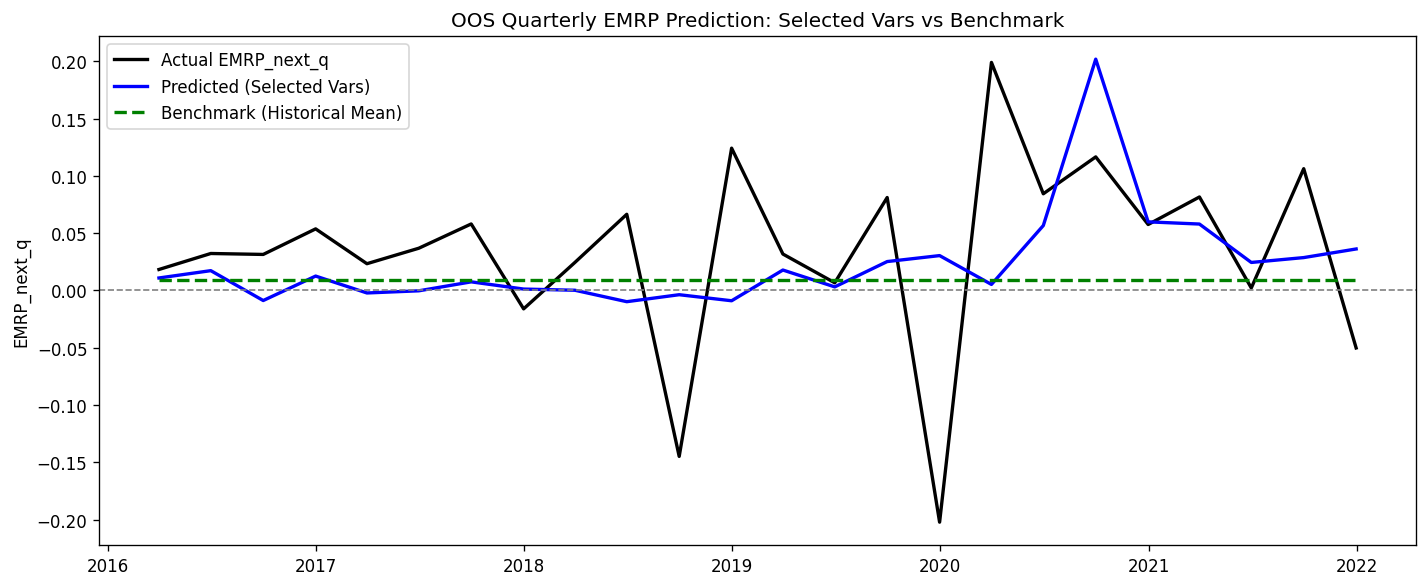

In [84]:
# ==============================================
# PLOT: OOS Selected-vars vs Benchmark
# ==============================================

plt.figure(figsize=(12,5))

# Actual data
plt.plot(
    y_test_sel.index, 
    y_test_sel, 
    label="Actual EMRP_next_q", 
    linewidth=2, 
    color="black"
)

# Selected-vars prediction
plt.plot(
    y_pred_sel.index, 
    y_pred_sel, 
    label="Predicted (Selected Vars)", 
    linewidth=2, 
    color="blue"
)

# Benchmark (historical mean)
plt.plot(
    y_bench.index, 
    y_bench, 
    label="Benchmark (Historical Mean)", 
    linewidth=2, 
    linestyle="--", 
    color="green"
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.title("OOS Quarterly EMRP Prediction: Selected Vars vs Benchmark")
plt.ylabel("EMRP_next_q")
plt.legend()
plt.tight_layout()
plt.show()

In [119]:
# ==============================================
# Convert Quarterly EMRP Forecast → Monthly
# ==============================================

# Quarterly predictions (from OOS regression)
pred_q = y_pred_sel.copy()
pred_q.index = pd.to_datetime(pred_q.index)   # ensure timestamps

# Convert quarterly → monthly by forward-fill
pred_m = pred_q.resample("M").ffill()

# Convert to PeriodIndex (to match trading dataset)
pred_m.index = pred_m.index.to_period("M")

print("Converted monthly prediction shape:", pred_m.shape)
pred_m.head()

Converted monthly prediction shape: (70,)


date
2016-03    0.010917
2016-04    0.010917
2016-05    0.010917
2016-06    0.017310
2016-07    0.017310
Freq: M, dtype: float64

In [121]:
# ==============================================
# Rebuild Monthly Trading Dataset (sp500 + rf)
# ==============================================

# --- S&P 500 monthly returns ---
sp500_m = sp500.resample("M").last()
sp500_level = sp500_m["SP500"]
sp500_ret = sp500_level.pct_change().dropna()
sp500_ret.index = sp500_ret.index.to_period("M")

# --- T-bill monthly returns ---
tbill_m = tbill.resample("M").last()
rf_ann = tbill_m["TB3MS"] / 100.0
rf_m = (1 + rf_ann)**(1/12) - 1
rf_m = rf_m.dropna()
rf_m.index = rf_m.index.to_period("M")

# Align monthly series
idx = sp500_ret.index.intersection(rf_m.index)
sp500_ret = sp500_ret.loc[idx]
rf_m = rf_m.loc[idx]

# Combine
data = pd.DataFrame({
    "sp500_ret": sp500_ret,
    "rf_ret": rf_m
})
data["erp"] = data["sp500_ret"] - data["rf_ret"]

print("Trading dataset shape:", data.shape)
data.head()

Trading dataset shape: (431, 3)


,sp500_ret,rf_ret,erp
date,,,
1990-01,-0.068817,0.006434,-0.075251
1990-02,0.008539,0.006465,0.002074
1990-03,0.024255,0.006488,0.017767
1990-04,-0.026887,0.006488,-0.033375
1990-05,0.091989,0.006442,0.085547


In [122]:
# ==============================================
# Align Monthly Predictions with Trading Dataset
# ==============================================

# Months where we have BOTH prediction AND trading data
valid_idx = pred_m.index.intersection(data.index)
print("Valid OOS period:", valid_idx.min(), "→", valid_idx.max())

data_oos = data.loc[valid_idx].copy()
pred_oos = pred_m.loc[valid_idx].copy()

print("OOS trading dataset:", data_oos.shape)
print("OOS prediction series:", pred_oos.shape)

data_oos.head(), pred_oos.head()

Valid OOS period: 2016-03 → 2021-12
OOS trading dataset: (70, 3)
OOS prediction series: (70,)


(         sp500_ret    rf_ret       erp
 date                                  
 2016-03   0.065991  0.000175  0.065816
 2016-04   0.002699  0.000183  0.002516
 2016-05   0.015329  0.000283  0.015047
 2016-06   0.000906  0.000216  0.000690
 2016-07   0.035610  0.000233  0.035377,
 date
 2016-03    0.010917
 2016-04    0.010917
 2016-05    0.010917
 2016-06    0.017310
 2016-07    0.017310
 Freq: M, dtype: float64)

In [123]:
# ==============================================
# Trading Strategies
# ==============================================

# Strategy A: Continuous allocation proportional to predicted EMRP
w_stock_A = pred_oos.clip(-0.5, 0.5)   # avoid excessive leverage
w_bond_A = 1 - w_stock_A

ret_A = w_stock_A * data_oos["sp500_ret"] + w_bond_A * data_oos["rf_ret"]

# Strategy B: Sign-based regime switching (long S&P if EMRP > 0)
w_stock_B = (pred_oos > 0).astype(float)
w_bond_B = 1 - w_stock_B

ret_B = w_stock_B * data_oos["sp500_ret"] + w_bond_B * data_oos["rf_ret"]

# Benchmark: 100% S&P 500 (Buy & Hold)
ret_bench = data_oos["sp500_ret"]

In [124]:
# ==============================================
# Performance Evaluation
# ==============================================

def sharpe(r):
    return np.sqrt(12) * r.mean() / r.std()

perf = pd.DataFrame({
    "Strategy_A": ret_A,
    "Strategy_B": ret_B,
    "Benchmark": ret_bench
})

cum = (1 + perf).cumprod()

print("Sharpe Ratios:")
print("Strategy A:", sharpe(ret_A))
print("Strategy B:", sharpe(ret_B))
print("Benchmark:", sharpe(ret_bench))

Sharpe Ratios:
Strategy A: 1.4499046991433016
Strategy B: 1.167533404234844
Benchmark: 1.1420640500667498


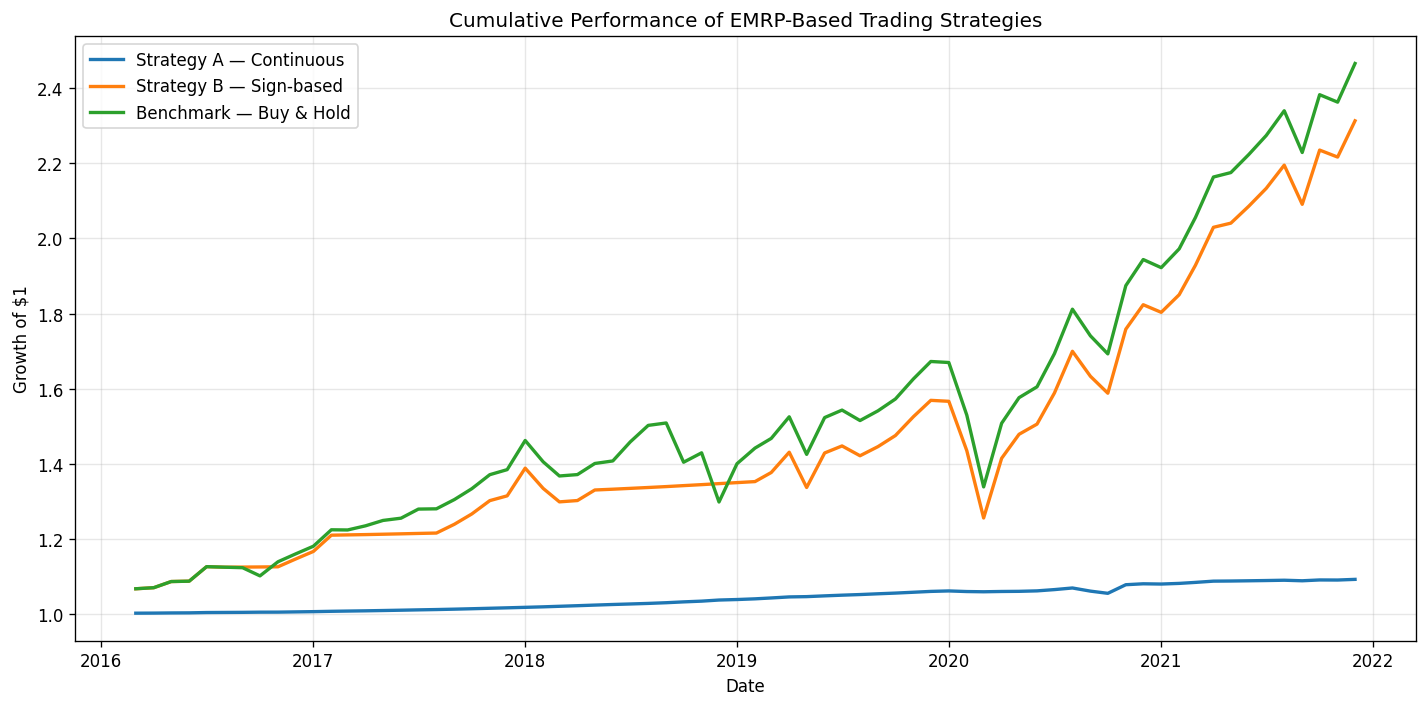

In [125]:
# ==============================================
# Plot Cumulative Performance
# ==============================================

plt.figure(figsize=(12,6))
plt.plot(cum.index.to_timestamp(), cum["Strategy_A"], label="Strategy A — Continuous", linewidth=2)
plt.plot(cum.index.to_timestamp(), cum["Strategy_B"], label="Strategy B — Sign-based", linewidth=2)
plt.plot(cum.index.to_timestamp(), cum["Benchmark"], label="Benchmark — Buy & Hold", linewidth=2)

plt.title("Cumulative Performance of EMRP-Based Trading Strategies")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()